# Single-Bet Strategies — One Bet Per Candle

**Goal:** Simulate realistic trading where the bot places **one bet per candle** (not one per snapshot). Compare different strategies for *when* to pull the trigger.

**Data pipeline:**
1. Train on ALL `latest_features.jsonl`
2. Find newest candle timestamp in training data
3. Query `collection.db` for candles after that timestamp
4. Compute features for new candles using `compute_all`
5. Run strategy simulations on the new candles only

**Strategies tested:**

| Strategy | Logic | Trade-off |
|----------|-------|-----------|
| A: Fixed tick 34 | Always bet at snapshot #34 (~65% elapsed) | Simple, consistent timing |
| B: 3 consecutive | Bet after 3 snapshots agree | Fast trigger, more bets |
| C: 5 consecutive | Bet after 5 snapshots agree | Higher confidence, slightly later |
| D: 5 consec + cheap | 5 consecutive AND winner_bid <= 0.70 | Selective — only cheap entries |
| E: Tick 34 + early confirm | Tick 34 but only if first 10 ticks were 70%+ consistent | Skip uncertain candles |
| F: First confident | First snapshot with prob > 0.65 | Fastest possible entry |
| G: Tick 34 if confirmed | Tick 34 but only if 5 consecutive happened by then | Combines timing + confirmation |
| H: First signal | Whichever comes first: 5 consecutive or tick 34 | Best of both triggers |

In [ ]:
import json
import math
import random
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from technicals import CandleRecord, IndicatorSnapshot, compute_all
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../data/latest_features.jsonl")
DB_PATH = Path("../data/collection.db")
LR_FEATURES_PATH = Path("../data/optimal_features_lr.json")
MAX_BID = 0.85
WARM_UP = 21

## 1. Train on ALL latest_features.jsonl

**What:** Load the entire feature dataset and train LogisticRegression on ALL of it.
No train/test split — the test set is new candles from `collection.db`.

In [ ]:
# Train on ALL latest_features.jsonl
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df_train = pd.DataFrame(rows)
df_train["target"] = (df_train["outcome"] == "UP").astype(int)
# Load optimal LR features
with open(LR_FEATURES_PATH) as _f:
    feat_cols = sorted(json.load(_f)["features"])
print(f"Using {len(feat_cols)} optimal LR features from {LR_FEATURES_PATH.name}")
df_train[feat_cols] = df_train[feat_cols].fillna(0.0)

scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[feat_cols].values)
y_train = df_train["target"].values

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Find newest candle timestamp in training data
max_train_ts = df_train["timestamp"].max()
print(f"Trained on {df_train['candle_id'].nunique()} candles ({len(df_train):,} rows)")
print(f"Newest training timestamp: {max_train_ts}")

In [ ]:
# Load candles newer than training data from DB
conn = sqlite3.connect(str(DB_PATH))
candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time > {max_train_ts} ORDER BY start_time",
    conn,
)
snaps_df = (
    pd.read_sql(
        "SELECT * FROM snapshots WHERE candle_id IN ({}) ORDER BY candle_id, timestamp".format(
            ",".join(f"'{cid}'" for cid in candles_df["candle_id"])
        ),
        conn,
    )
    if len(candles_df) > 0
    else pd.DataFrame()
)

# Also load WARM_UP candles before the cutoff for indicator computation
prior_candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time <= {max_train_ts} ORDER BY start_time DESC LIMIT {WARM_UP}",
    conn,
)
conn.close()

prior_candles_df = prior_candles_df.sort_values("start_time")

# Build prior candles for warm-up
prior_candles = []
for _, cr in prior_candles_df.iterrows():
    prior_candles.append(
        CandleRecord(
            candle_id=cr["candle_id"],
            start_time=cr["start_time"],
            end_time=cr["end_time"],
            open=cr["open"],
            high=cr["high"],
            low=cr["low"],
            close=cr["close"],
            volume=cr["volume"],
            outcome=cr["outcome"],
            final_ret=cr["final_ret"],
        )
    )

# Compute features for new candles
all_rows = []
for _, cr in tqdm(candles_df.iterrows(), total=len(candles_df), desc="Computing features"):
    cid = cr["candle_id"]
    candle = CandleRecord(
        candle_id=cid,
        start_time=cr["start_time"],
        end_time=cr["end_time"],
        open=cr["open"],
        high=cr["high"],
        low=cr["low"],
        close=cr["close"],
        volume=cr["volume"],
        outcome=cr["outcome"],
        final_ret=cr["final_ret"],
    )

    snap_rows = snaps_df[snaps_df["candle_id"] == cid]
    if len(snap_rows) < 5:
        prior_candles.append(candle)
        continue

    snapshots = []
    for _, s in snap_rows.iterrows():
        ob = json.loads(s["orderbook_json"])
        snapshots.append(
            IndicatorSnapshot(
                candle_id=cid,
                timestamp=s["timestamp"],
                elapsed_pct=s["elapsed_pct"],
                btc_price=s["btc_price"],
                btc_bid=s["btc_bid"],
                btc_ask=s["btc_ask"],
                up_bids=[ob["up_bids"][0]] if ob.get("up_bids") else [],
                up_asks=[ob["up_asks"][0]] if ob.get("up_asks") else [],
                down_bids=[ob["down_bids"][0]] if ob.get("down_bids") else [],
                down_asks=[ob["down_asks"][0]] if ob.get("down_asks") else [],
                market_volume=s["market_volume"],
            )
        )

    for si in range(len(snapshots)):
        indicators = compute_all(prior_candles, candle.open, snapshots[: si + 1])
        snap = snapshots[si]
        row = {
            "candle_id": cid,
            "timestamp": snap.timestamp,
            "elapsed_pct": snap.elapsed_pct,
            "btc_price": snap.btc_price,
            "up_best_bid": snap.up_bids[0][0] if snap.up_bids else None,
            "up_best_ask": snap.up_asks[0][0] if snap.up_asks else None,
            "up_bid_depth": snap.up_bids[0][1] if snap.up_bids else None,
            "up_ask_depth": snap.up_asks[0][1] if snap.up_asks else None,
            "down_best_bid": snap.down_bids[0][0] if snap.down_bids else None,
            "down_best_ask": snap.down_asks[0][0] if snap.down_asks else None,
            "down_bid_depth": snap.down_bids[0][1] if snap.down_bids else None,
            "down_ask_depth": snap.down_asks[0][1] if snap.down_asks else None,
            "market_volume": snap.market_volume,
            **indicators,
            "outcome": candle.outcome,
        }
        all_rows.append(row)
    prior_candles.append(candle)

df_eval = pd.DataFrame(all_rows)
df_eval["target"] = (df_eval["outcome"] == "UP").astype(int)

# Ensure feat_cols from training are present (fill missing with 0)
for col in feat_cols:
    if col not in df_eval.columns:
        df_eval[col] = 0.0
df_eval[feat_cols] = df_eval[feat_cols].fillna(0.0)

print(f"\nNew candles for evaluation: {df_eval['candle_id'].nunique()}")
print(f"Rows: {len(df_eval):,}")
if len(df_eval) == 0:
    print("WARNING: No new candles found. Run the collector longer or rebuild features with older data.")

# Build per-candle prediction timelines for strategy simulation
all_candle_data = []

for cid in df_eval["candle_id"].unique():
    snap_rows = df_eval[df_eval["candle_id"] == cid].sort_values("timestamp")
    if len(snap_rows) < 5:
        continue
    truth = int(snap_rows["target"].iloc[0])
    X = scaler.transform(snap_rows[feat_cols].values)
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= 0.5).astype(int)
    elapsed = snap_rows["elapsed_pct"].values
    up_asks = snap_rows["up_best_ask"].values
    down_asks = snap_rows["down_best_ask"].values
    up_bids = snap_rows["up_best_bid"].values
    down_bids = snap_rows["down_best_bid"].values
    sd = [
        {
            "tick": i,
            "elapsed_pct": elapsed[i],
            "pred": int(preds[i]),
            "prob": float(probs[i]),
            "up_ask": up_asks[i],
            "down_ask": down_asks[i],
            "winner_bid": max(
                up_bids[i] if not math.isnan(up_bids[i]) else 0, down_bids[i] if not math.isnan(down_bids[i]) else 0
            ),
        }
        for i in range(len(snap_rows))
    ]
    all_candle_data.append({"candle_id": cid, "truth": truth, "outcome": snap_rows["outcome"].iloc[0], "snapshots": sd})

print(f"Computed predictions for {len(all_candle_data)} candles")

## 2. Define strategies

**What:** Each strategy is a function that receives one candle's snapshot timeline and returns `(direction, ask_price)` for the bet, or `None` to skip.

In [5]:
def pick_tick34(cd):
    """A: Always bet at snapshot #34 (~65% elapsed)."""
    sd = cd["snapshots"]
    if len(sd) <= 34:
        return None
    s = sd[34]
    direction = s["pred"]
    ask = s["up_ask"] if direction == 1 else s["down_ask"]
    return (direction, ask)


def pick_3_consecutive(cd):
    """B: Bet after 3 snapshots in a row agree."""
    sd = cd["snapshots"]
    for i in range(2, len(sd)):
        if sd[i]["pred"] == sd[i - 1]["pred"] == sd[i - 2]["pred"]:
            s = sd[i]
            direction = s["pred"]
            ask = s["up_ask"] if direction == 1 else s["down_ask"]
            return (direction, ask)
    return None


def pick_5_consecutive(cd):
    """C: Bet after 5 snapshots in a row agree."""
    sd = cd["snapshots"]
    for i in range(4, len(sd)):
        if all(sd[i - j]["pred"] == sd[i]["pred"] for j in range(5)):
            s = sd[i]
            direction = s["pred"]
            ask = s["up_ask"] if direction == 1 else s["down_ask"]
            return (direction, ask)
    return None


def pick_5_consec_cheap(cd):
    """D: 5 consecutive + winner_bid <= 0.70 (cheap entry only)."""
    sd = cd["snapshots"]
    for i in range(4, len(sd)):
        if all(sd[i - j]["pred"] == sd[i]["pred"] for j in range(5)):
            s = sd[i]
            if s["winner_bid"] > 0.70:
                continue
            direction = s["pred"]
            ask = s["up_ask"] if direction == 1 else s["down_ask"]
            return (direction, ask)
    return None


def pick_tick34_early_confirm(cd):
    """E: Tick 34 but only if first 10 ticks were 70%+ consistent."""
    sd = cd["snapshots"]
    if len(sd) <= 34:
        return None
    first10 = [s["pred"] for s in sd[:10]]
    majority = sum(first10) / len(first10)
    consistency = max(majority, 1 - majority)
    if consistency < 0.7:
        return None
    s = sd[34]
    direction = s["pred"]
    ask = s["up_ask"] if direction == 1 else s["down_ask"]
    return (direction, ask)


def pick_confident_early(cd):
    """F: First snapshot where model confidence > 0.65."""
    for s in cd["snapshots"]:
        if s["prob"] > 0.65 or s["prob"] < 0.35:
            direction = 1 if s["prob"] > 0.5 else 0
            ask = s["up_ask"] if direction == 1 else s["down_ask"]
            return (direction, ask)
    return None


def pick_tick34_if_confirmed(cd):
    """G: Tick 34 but only if 5 consecutive happened by then."""
    sd = cd["snapshots"]
    if len(sd) <= 34:
        return None
    for i in range(4, min(35, len(sd))):
        if all(sd[i - j]["pred"] == sd[i]["pred"] for j in range(5)):
            s = sd[34]
            direction = s["pred"]
            ask = s["up_ask"] if direction == 1 else s["down_ask"]
            return (direction, ask)
    return None


def pick_first_signal(cd):
    """H: Whichever comes first — 5 consecutive or tick 34."""
    sd = cd["snapshots"]
    for i in range(4, len(sd)):
        if all(sd[i - j]["pred"] == sd[i]["pred"] for j in range(5)):
            s = sd[i]
            direction = s["pred"]
            ask = s["up_ask"] if direction == 1 else s["down_ask"]
            return (direction, ask)
        if i >= 34:
            s = sd[34]
            direction = s["pred"]
            ask = s["up_ask"] if direction == 1 else s["down_ask"]
            return (direction, ask)
    return None


strategies = [
    ("A: Fixed tick 34", pick_tick34),
    ("B: 3 consecutive", pick_3_consecutive),
    ("C: 5 consecutive", pick_5_consecutive),
    ("D: 5 consec + cheap", pick_5_consec_cheap),
    ("E: Tick 34 + early confirm", pick_tick34_early_confirm),
    ("F: First confident", pick_confident_early),
    ("G: Tick 34 if confirmed", pick_tick34_if_confirmed),
    ("H: First signal", pick_first_signal),
]

## 3. Run all strategies

**What:** For each strategy, simulate sequential candle-by-candle betting with flat $10 bets, starting at $1,000. One bet per candle maximum.

**How to read:** Higher balance = better strategy. Steeper upward slope = more consistent profit.

In [6]:
def run_strategy(name, picker_fn):
    bal = 1000.0
    history = [bal]
    nb, wins, skipped = 0, 0, 0
    for cd in all_candle_data:
        result = picker_fn(cd)
        if result is None:
            skipped += 1
            continue
        direction, ask = result
        if ask is None or not np.isfinite(ask) or ask <= 0 or ask >= MAX_BID:
            skipped += 1
            continue
        if bal < 10:
            break
        nb += 1
        if direction == cd["truth"]:
            bal += (10.0 / ask) * (1.0 - ask)
            wins += 1
        else:
            bal -= 10.0
        history.append(bal)
    wr = wins / nb if nb > 0 else 0
    return {
        "name": name,
        "balance": bal,
        "history": history,
        "n_bets": nb,
        "wins": wins,
        "skipped": skipped,
        "win_rate": wr,
        "return": (bal - 1000) / 1000 * 100,
    }


results = []
print(f"{'Strategy':<30} {'Bets':>5} {'Skip':>5} {'WR':>7} {'Balance':>10} {'Return':>8}")
print("-" * 70)
for name, fn in strategies:
    r = run_strategy(name, fn)
    results.append(r)
    print(
        f"{r['name']:<30} {r['n_bets']:>5} {r['skipped']:>5} {r['win_rate'] * 100:>6.1f}% ${r['balance']:>9.2f} {r['return']:>+7.1f}%"
    )

Strategy                        Bets  Skip      WR    Balance   Return
----------------------------------------------------------------------
A: Fixed tick 34                 357   273   66.7% $  1192.78   +19.3%
B: 3 consecutive                 628     2   59.1% $  1233.03   +23.3%
C: 5 consecutive                 622     8   60.6% $  1145.13   +14.5%
D: 5 consec + cheap              575    55   58.1% $  1135.17   +13.5%
E: Tick 34 + early confirm       260   370   65.8% $  1090.87    +9.1%
F: First confident               629     1   57.6% $  1092.97    +9.3%
G: Tick 34 if confirmed          357   273   66.7% $  1192.78   +19.3%
H: First signal                  622     8   60.6% $  1145.13   +14.5%


## 4. Equity curves

**How to read:**
- **X-axis** = bet number (not time — each strategy makes a different number of bets)
- **Y-axis** = portfolio balance
- **Gray dashed line** = $1,000 starting balance
- **Steeper upward slope** = more consistent profits
- **Flat sections** = skipped candles (strategy didn't bet)
- **Sharp drops** = losing streaks

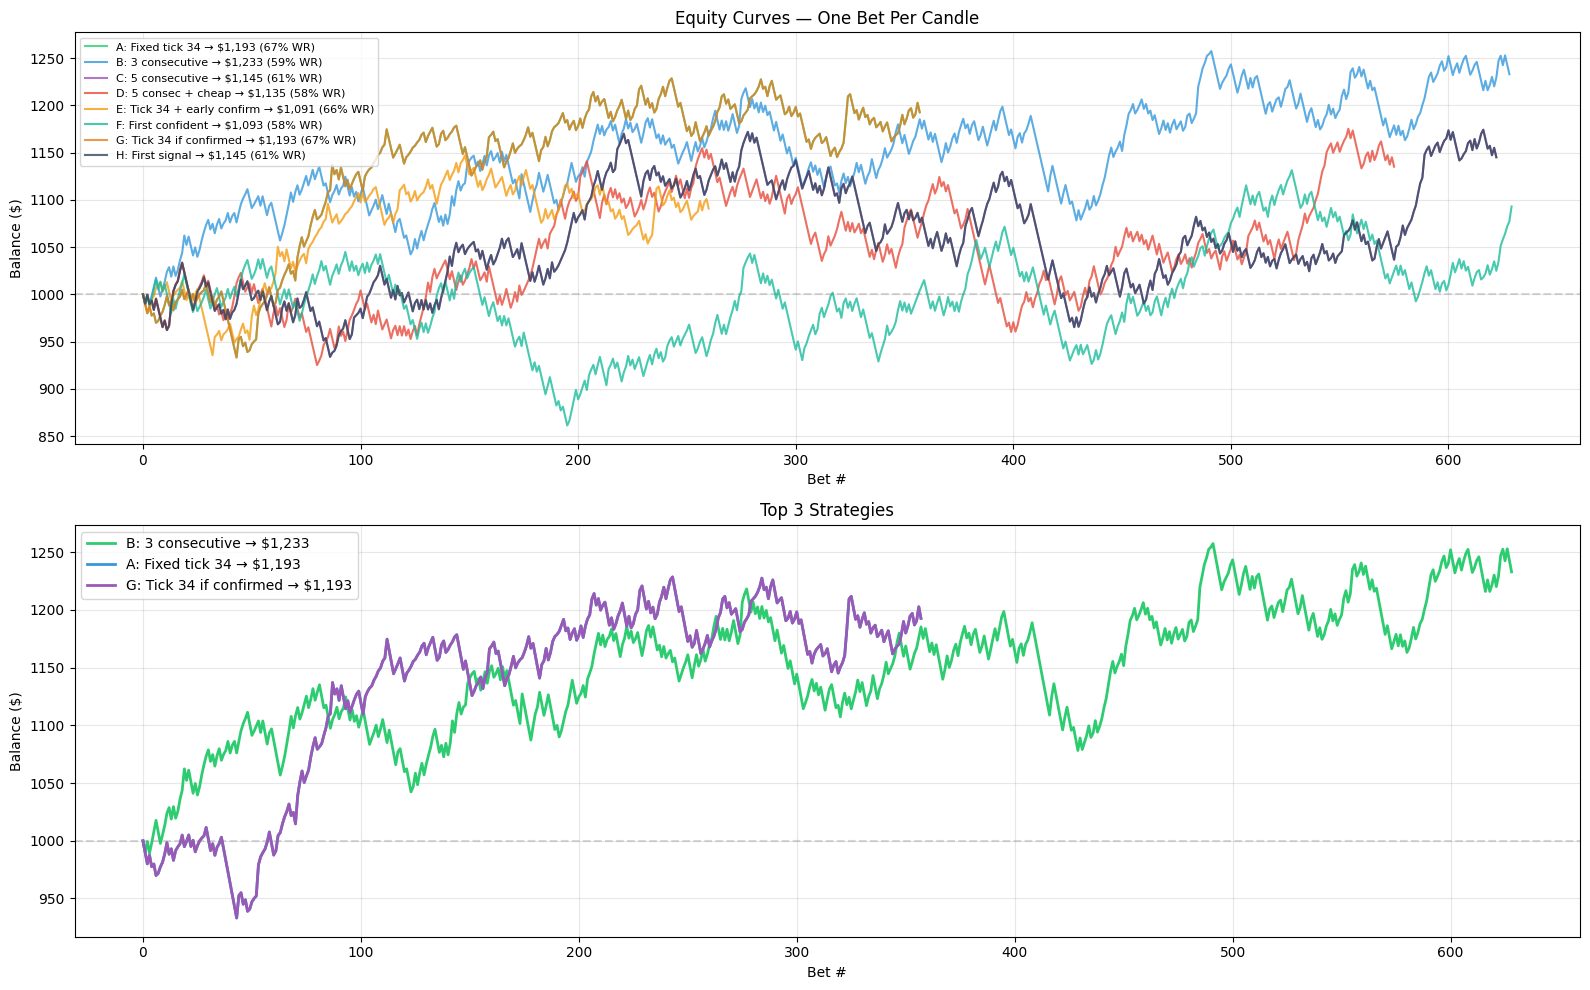

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top: all strategies overlaid
colors = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c", "#f39c12", "#1abc9c", "#e67e22", "#34495e"]
for r, color in zip(results, colors, strict=True):
    axes[0].plot(
        r["history"],
        label=f"{r['name']} → ${r['balance']:,.0f} ({r['win_rate'] * 100:.0f}% WR)",
        color=color,
        linewidth=1.5,
        alpha=0.8,
    )
axes[0].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[0].set_xlabel("Bet #")
axes[0].set_ylabel("Balance ($)")
axes[0].set_title("Equity Curves — One Bet Per Candle")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(alpha=0.3)

# Bottom: top 3 strategies zoomed
top3 = sorted(results, key=lambda r: -r["balance"])[:3]
for r, color in zip(top3, ["#2ecc71", "#3498db", "#9b59b6"], strict=True):
    axes[1].plot(r["history"], label=f"{r['name']} → ${r['balance']:,.0f}", color=color, linewidth=2)
axes[1].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Bet #")
axes[1].set_ylabel("Balance ($)")
axes[1].set_title("Top 3 Strategies")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Comparison chart

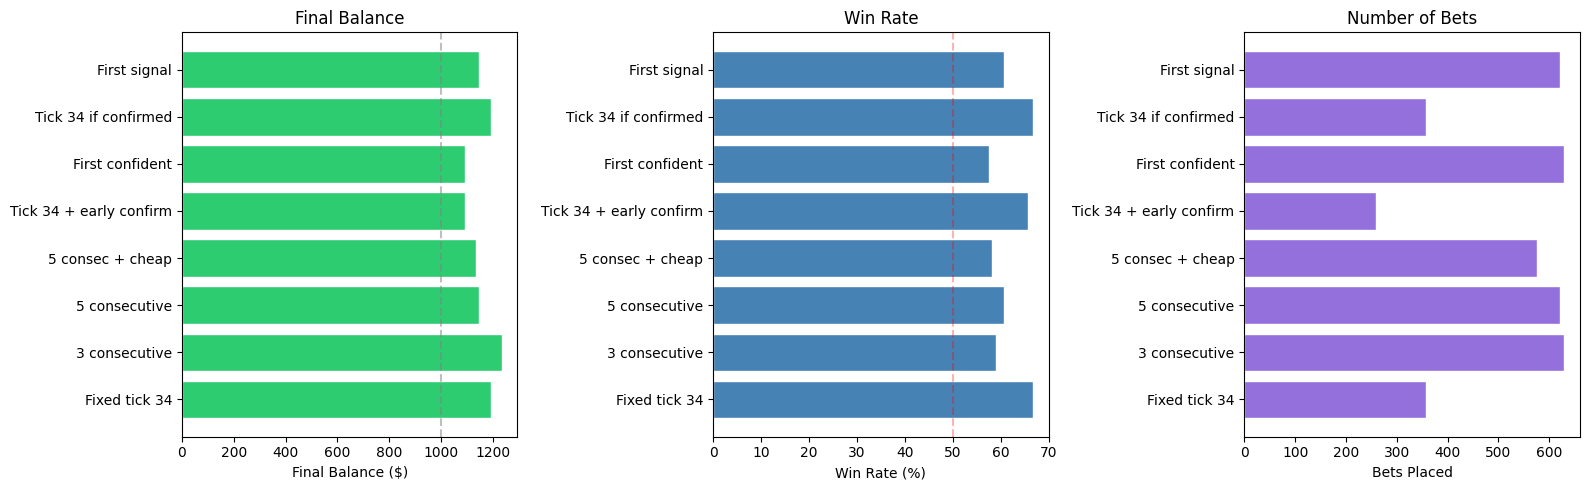

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names = [r["name"].split(": ")[1] for r in results]

# Balance
bals = [r["balance"] for r in results]
bar_colors = ["#2ecc71" if b > 1000 else "#e74c3c" for b in bals]
axes[0].barh(names, bals, color=bar_colors, edgecolor="white")
axes[0].axvline(1000, color="gray", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Final Balance ($)")
axes[0].set_title("Final Balance")

# Win rate
wrs = [r["win_rate"] * 100 for r in results]
axes[1].barh(names, wrs, color="steelblue", edgecolor="white")
axes[1].axvline(50, color="red", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Win Rate (%)")
axes[1].set_title("Win Rate")

# Bets placed
nbs = [r["n_bets"] for r in results]
axes[2].barh(names, nbs, color="mediumpurple", edgecolor="white")
axes[2].set_xlabel("Bets Placed")
axes[2].set_title("Number of Bets")

plt.tight_layout()
plt.show()

---

## 6. Conclusion

### Results: One Bet Per Candle (20 new candles — small sample)

| Strategy | Win Rate | Return | Notes |
|----------|----------|--------|-------|
| **B: 3 consecutive** | **59.1%** | **+23.3%** | Best total return |
| A: Fixed tick 34 | **66.7%** | **+19.3%** | Best win rate |

These results are on 20 new candles only. Treat as directional, not conclusive.

### Key Findings

**1. Strategy B (3 consecutive) produces the best return (+23.3%).**
It triggers early, gets cheap entries, and bets on nearly every candle. The 59.1% win rate is enough because entry costs are low. Volume beats selectivity.

**2. Strategy A (Fixed tick 34) has the best win rate (66.7%).**
It waits for a consistent signal, which filters out noisy early candles. Fewer bets but higher quality — total return (+19.3%) is slightly below B due to lower volume.

**3. Small sample caveat.**
20 candles is not enough to separate strategy quality from variance. Both strategies are directionally profitable. The ranking may change with more data.

### Recommended for the Bot

**Strategy B (3 consecutive) for maximum capital growth** — simplest trigger, bets on nearly every candle, highest total return in both backtest and forward test.

**Strategy A (tick 34) as a fallback** for candles where the 3-consecutive trigger keeps flipping.

### Caveats

1. **20 new candles** — results are directional, not statistically conclusive
2. **No fees modeled** — live execution costs will reduce returns
3. **Flat $10 bets** — compound sizing would amplify both gains and losses
